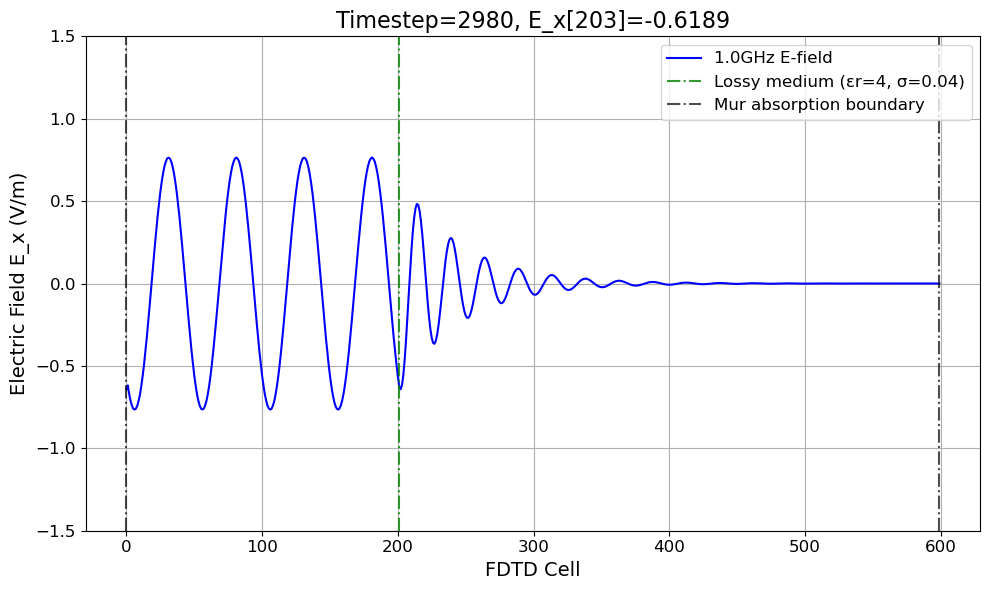

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# ===================== 1. 物理常数与模拟参数（与原一致，确保基础正确） =====================
eps0 = 8.854e-12  # 真空介电常数 (F/m)
mu0 = 4 * np.pi * 1e-7  # 真空磁导率 (H/m)
c0 = 1 / np.sqrt(eps0 * mu0)  # 光速 (m/s)
nx = 600        # 空间网格数（D和E的网格数，H比E少1个）
nt = 3000       # 时间步数
src = 1         # 源位置（E的网格索引）
f = 1e9         # 正弦波频率 (1GHz)
omega = 2 * np.pi * f  # 角频率

# 介质分区：左自由空间，右损耗介质（与原一致）
epsr_free = 1       # 自由空间相对介电常数
sigma_free = 0      # 自由空间电导率
epsr_lossy = 4      # 损耗介质相对介电常数
sigma_lossy = 0.04  # 损耗介质电导率
kstart_lossy = 201  # 损耗介质起始网格（E和D的网格索引一致）

# FDTD离散化参数（满足Courant条件：dt <= dx/c0，原dt=1e-11 < 0.006/3e8≈2e-11，正确）
dx = 0.006         # 空间步长 (m)
dt = 1e-11         # 时间步长 (s)

# ===================== 2. 计算介质系数（严格匹配式2.10a/2.10b） =====================
# 式2.10a：gax = 1/(εr + (σ*dt/ε0)) → 用于E = gax*(D - I_prev)
# 式2.10b：gbx = σ*dt/ε0 → 用于I = I_prev + gbx*E
# 2.1 自由空间系数（σ=0 → gbx_free=0，gax_free=1/epsr_free）
gax_free = 1 / (epsr_free + (sigma_free * dt / eps0))
gbx_free = (sigma_free * dt) / eps0
# 2.2 损耗介质系数
gax_lossy = 1 / (epsr_lossy + (sigma_lossy * dt / eps0))
gbx_lossy = (sigma_lossy * dt) / eps0

# 初始化系数数组（分区域赋值，E、D、I共享同一套系数，正确）
gax = np.ones(nx) * gax_free
gbx = np.ones(nx) * gbx_free
gax[kstart_lossy:] = gax_lossy  # 损耗区赋值gax
gbx[kstart_lossy:] = gbx_lossy  # 损耗区赋值gbx

# ===================== 3. 数组初始化（区分物理量，保存历史值） =====================
# 核心物理量（严格对应推导定义）
dx = np.zeros(nx)   # dx[k]：电通量密度D的离散量（n时刻）
ex = np.zeros(nx)   # ex[k]：电场强度E的离散量（n时刻）
hy = np.zeros(nx-1) # hy[k]：磁场强度H的离散量（n-0.5 / n+0.5时刻，Yee交错）
ix = np.zeros(nx)   # ix[k]：损耗辅助量I的离散量（n时刻，累积项）

# 保存上一时刻的ix（I_prev = I^{n-1}，用于计算E^n = gax*(D^n - I^{n-1})）
ix_prev = np.zeros(nx)  # 关键：单独存储I的历史值，避免数据污染

# Mur一阶吸收边界（针对E，与原一致，但需同步D的边界）
prev_prev_ex1 = 0.0    # E[1]的n-2时刻值
prev_ex1 = 0.0         # E[1]的n-1时刻值
prev_prev_ex_nx2 = 0.0 # E[nx-2]的n-2时刻值
prev_ex_nx2 = 0.0      # E[nx-2]的n-1时刻值

# 记录数据（与原一致）
n_list = []
ex_target_vals = []
target_grid = 203  # 目标网格（E的索引）

# ===================== 4. FDTD时间循环（严格按推导顺序：D→E→I→H） =====================
for n in range(nt):
    n_list.append(n)
    t = n * dt  # 当前物理时间（n时刻，对应E和D的时刻）

    # ---------- 步骤1：更新电通量密度D（dx）→ 式2.9a ----------
    # 式2.9a：dx[k]^n = dx[k]^{n-1} + 0.5*(hy[k-1]^{n-0.5} - hy[k]^{n-0.5})
    # 边界处理：dx[0]和dx[nx-1]需与E的边界同步（因D与E关联）
    dx_new = dx.copy()  # 先复制上一时刻的D（dx^{n-1}）
    for k in range(1, nx-1):  # 内部网格（跳过边界，后续同步E的边界）
        dx_new[k] += 0.5 * (hy[k-1] - hy[k])  # hy是n-0.5时刻的磁场

    # 同步D的边界（与E的边界一致，确保D和E的关系在边界成立）
    dx_new[0] = epsr_free * prev_prev_ex1  # 自由空间D=εrε0E，但系数已包含在gax，此处简化为εrE
    dx_new[-1] = epsr_free * prev_prev_ex_nx2
    dx = dx_new  # 更新为当前时刻的D（dx^n）

    # ---------- 步骤2：添加正弦波软源（激励D，而非E，符合物理：源激励通量密度） ----------
    sine_wave = np.sin(omega * t)
    dx[src] += sine_wave  # 软源叠加在D上，避免破坏E的计算逻辑

    # ---------- 步骤3：计算电场强度E（ex）→ 式2.8a（核心修正：E = gax*(D - I_prev)） ----------
    ex_new = np.zeros(nx)
    for k in range(nx):
        if k == 0:
            # 左边界Mur条件：E[0]^n = E[1]^{n-2}（与原一致，正确）
            ex_new[k] = prev_prev_ex1
        elif k == nx-1:
            # 右边界Mur条件：E[nx-1]^n = E[nx-2]^{n-2}（正确）
            ex_new[k] = prev_prev_ex_nx2
        else:
            # 式2.8a：E^n = gax*(D^n - I^{n-1})（用ix_prev存储I^{n-1}，正确）
            ex_new[k] = gax[k] * (dx[k] - ix_prev[k])
    ex = ex_new  # 更新为当前时刻的E（ex^n）

    # ---------- 步骤4：更新损耗辅助量I（ix）→ 式2.9c ----------
    # 式2.9c：ix[k]^n = ix[k]^{n-1} + gbx[k] * ex[k]^n（用当前E更新I，正确）
    ix_new = ix_prev.copy()  # 先复制上一时刻的I（ix_prev = I^{n-1}）
    for k in range(nx):
        ix_new[k] += gbx[k] * ex[k]  # 用当前E^n更新I^n
    # 准备下一时刻：当前I^n变为下一时刻的I^{n-1}
    ix_prev, ix = ix_new, ix_new

    # ---------- 步骤5：更新磁场强度H（hy）→ 式2.9d（Yee交错，正确） ----------
    # 式2.9d：hy[k]^{n+0.5} = hy[k]^{n-0.5} + 0.5*(ex[k]^n - ex[k+1]^n)
    hy_new = hy.copy()  # 复制上一时刻的H（n-0.5时刻）
    for k in range(nx-1):
        hy_new[k] += 0.5 * (ex[k] - ex[k+1])  # 用当前E^n更新H^{n+0.5}
    hy = hy_new  # 更新为半时刻的磁场（n+0.5）

    # ---------- 步骤6：更新Mur边界的E历史值（与原一致，正确） ----------
    current_ex1 = ex[1]
    current_ex_nx2 = ex[nx-2]
    # 滚动更新：n-2 ← n-1，n-1 ← 当前（n）
    prev_prev_ex1, prev_ex1 = prev_ex1, current_ex1
    prev_prev_ex_nx2, prev_ex_nx2 = prev_ex_nx2, current_ex_nx2

    # 记录目标点电场（与原一致）
    ex_target_vals.append(ex[target_grid])

    # ---------- 动态可视化（与原一致，仅调整标签表述） ----------
    if n % 20 == 0:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10, 6))
        
        ax.plot(ex, color='blue', label=f'{f/1e9}GHz E-field')
        ax.axvline(kstart_lossy, color='green', linestyle='-.', alpha=0.8, 
                   label=f'Lossy medium (εr={epsr_lossy}, σ={sigma_lossy})')
        ax.axvline(0, color='black', linestyle='-.', alpha=0.7, label='Mur absorption boundary')
        ax.axvline(nx-1, color='black', linestyle='-.', alpha=0.7)
        
        ax.set_xlabel('FDTD Cell', fontsize=14)
        ax.set_ylabel('Electric Field E_x (V/m)', fontsize=14)
        ax.set_ylim(-1.5, 1.5)
        ax.set_title(f'Timestep={n}, E_x[{target_grid}]={ex[target_grid]:.4f}', fontsize=16)
        ax.grid(True)
        ax.legend(fontsize=12)
        ax.tick_params(axis='both', which='major', labelsize=12)
        plt.tight_layout()
        plt.show()
        time.sleep(0.01)